
-----

## **EDA Tips and Tricks**

-----



### **Import Libraries**

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

### **Load Dataset**

- Load titaniic dataset from **Seaborn** library.

In [2]:
data = sns.load_dataset("titanic")
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### **Let's Check missing Values**

In [3]:
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
# Calculate the percentage of missing values and sort in descending order
missing_percentage = (data.isnull().sum() / len(data)) * 100
sorted_missing = missing_percentage.sort_values(ascending=False)

# Display the result
print(sorted_missing)

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
survived        0.000000
pclass          0.000000
sex             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
class           0.000000
who             0.000000
adult_male      0.000000
alive           0.000000
alone           0.000000
dtype: float64


### **Drop columns**

> As we can see `deck` column has __77.216611__ percent missing values.\
> 
> We usually drop columns with more than __70 percent__ missing values.\
> 
>  So we will drop this column

In [6]:
# drop "deck" column from dataset permanently

data.drop('deck',axis=1,inplace=True)

### **Filling missing Values of `age` column with mean**

In [10]:
data['age'].fillna(data['age'].mean(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_3844\1829737370.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].mean(), inplace=True)


In [11]:
# check age column once again
data.isnull().sum() 

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

> We see missing values in embark_town and embarked we need to dea with this too.

### **Fill missing values in `embarked` and `embark_town` with mode**

In [12]:
data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)
data['embark_town'].fillna(data['embark_town'].mode()[0], inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_3844\880237249.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['embark_town'].fillna(data['embark_town'].mode()[0], inplace=True)


In [13]:
# check missing values again

data.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

<Axes: >

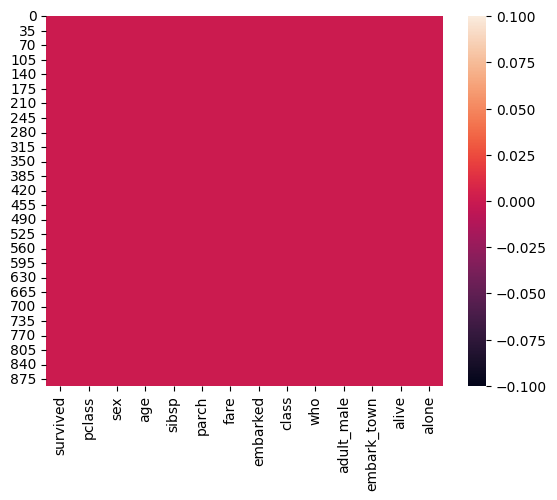

In [14]:
# Let's plot missing values

sns.heatmap(data.isnull())

### **Data Binning**

- Now let's discuss another topic which is binnig or data discretization.

In [15]:
# check minimum value in age column

data['age'].min()

0.42

In [16]:
# check maximum value in age column

data['age'].max()

80.0

<Axes: xlabel='age', ylabel='Count'>

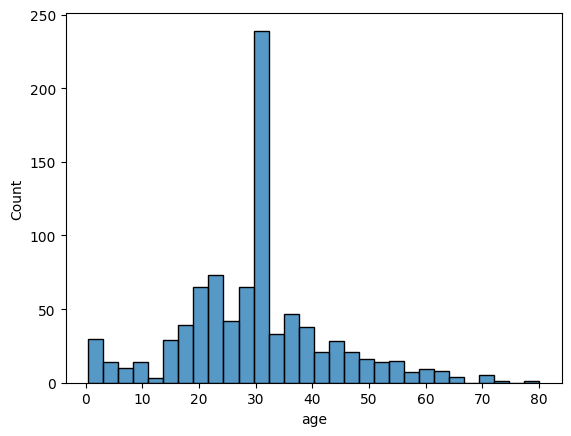

In [18]:
# histogram of age column

sns.histplot(data['age'])

In [19]:

# binning of data columns in 7 catageories

bins = [0,1,5,12,18,30,50,80]
labels = ['Infants','Toddlers','Kids','Teens','Youngs','Middle Aged','Old']

# make binning of age column
pd.cut(data["age"],bins=bins,labels=labels)

0           Youngs
1      Middle Aged
2           Youngs
3      Middle Aged
4      Middle Aged
          ...     
886         Youngs
887         Youngs
888         Youngs
889         Youngs
890    Middle Aged
Name: age, Length: 891, dtype: category
Categories (7, object): ['Infants' < 'Toddlers' < 'Kids' < 'Teens' < 'Youngs' < 'Middle Aged' < 'Old']

### **Feature Engineering**

In [20]:

# binning of data columns in 7 catageories

bins = [0,1,5,12,18,30,50,80]
labels = ['Infants','Toddlers','Kids','Teens','Youngs','Middle Aged','Old']

# make binning of age column
data['binned_age'] = pd.cut(data["age"],bins=bins,labels=labels)

In [21]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,binned_age
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Youngs
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Middle Aged
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Youngs
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Middle Aged
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Middle Aged


In [22]:
data['binned_age'].value_counts()

binned_age
Youngs         447
Middle Aged    241
Teens           70
Old             64
Toddlers        30
Kids            25
Infants         14
Name: count, dtype: int64

In [23]:
# rename a column

data.rename(columns={'binned_age': "age_groups"},inplace=True)

In [24]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_groups
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Youngs
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Middle Aged
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Youngs
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Middle Aged
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Middle Aged


In [ ]:

'the count of survivors (1) and non-survivors (0) for each age group, you can use the groupby function along with value_counts'

# Group by age groups and count the survived status
survival_counts = data.groupby('age_groups')['survived'].value_counts().unstack(fill_value=0)

# Display the result
print(survival_counts) 

survived       0    1
age_groups           
Infants        2   12
Toddlers      11   19
Kids          16    9
Teens         40   30
Youngs       299  148
Middle Aged  139  102
Old           42   22


C:\Users\user\AppData\Local\Temp\ipykernel_3844\386380694.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_counts = data.groupby('age_groups')['survived'].value_counts().unstack(fill_value=0)


### **Data Filtration**

- We can select some columns based on our requirements

In [34]:
data_1 = data[['survived','age_groups','fare','class']]

In [35]:
data_1.head()

,survived,age_groups,fare,class
0,0,Youngs,7.2500,Third
1,1,Middle Aged,71.2833,First
2,1,Youngs,7.9250,Third
3,1,Middle Aged,53.1000,First
4,0,Middle Aged,8.0500,Third


In [36]:
# filter the data based on row criteria
data_1[data_1['class'] == 'First']

,survived,age_groups,fare,class
1,1,Middle Aged,71.2833,First
3,1,Middle Aged,53.1000,First
6,0,Old,51.8625,First
11,1,Old,26.5500,First
23,1,Youngs,35.5000,First
...,...,...,...,...
871,1,Middle Aged,52.5542,First
872,0,Middle Aged,5.0000,First
879,1,Old,83.1583,First
887,1,Youngs,30.0000,First


In [37]:
data_1[data_1['fare'] > 200]

,survived,age_groups,fare,class
27,0,Youngs,263.0000,First
88,1,Youngs,263.0000,First
118,0,Youngs,247.5208,First
258,1,Middle Aged,512.3292,First
299,1,Middle Aged,247.5208,First
311,1,Teens,262.3750,First
341,1,Youngs,263.0000,First
377,0,Youngs,211.5000,First
380,1,Middle Aged,227.5250,First
438,0,Old,263.0000,First


----